In [1]:
!pip install category_encoders


In [2]:
# ====================================================================
# BLOCK 1: LIBRARIES & SETUP
# ====================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_auc_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ====================================================================
# BLOCK 2: DATA LOADING & FEATURE ENGINEERING
# ====================================================================
file_name = 'challenge_train.xlsx' # Adjust to CSV if necessary
df = pd.read_excel(file_name)

eps = 1e-6

# 1. Demographics
df['date_of_incorporation'] = pd.to_datetime(df['Date of incorporation'], errors='coerce')
df['firm_age'] = 2018 - df['date_of_incorporation'].dt.year
df['naics_2digit'] = df['NAICS 2022, core code (4 digits)'].astype(str).str[:2]

# 2. Extract Data & Calculate Base Ratios for 2016, 2017, 2018
ratio_map = {
    1: "working_capital_to_assets",
    2: "ebit_to_assets",
    3: "equity_to_assets",
    4: "debt_to_assets",
    5: "sales_to_assets",
    6: "financial_expenses_to_revenue"
}

years = [2016, 2017, 2018]
for yr in years:
    ta = df[f'Total assets th EUR {yr}']
    ca = df[f'Current assets th EUR {yr}']
    cl = df[f'Current liabilities th EUR {yr}']
    sf = df[f'Shareholders funds th EUR {yr}']
    ebit = df[f'Operating profit (loss) [EBIT] th EUR {yr}']
    sales = df[f'Sales th EUR {yr}']
    rev = df[f'Operating revenue (Turnover) th EUR {yr}']
    fe = df[f'Financial expenses th EUR {yr}']
    debt = df[f'Long term debt th EUR {yr}'] + df[f'Loans & short-term debt th EUR {yr}']

    df[f'working_capital_to_assets_{yr}']        = ((ca - cl) / (ta + eps)).clip(-5, 5)
    df[f'ebit_to_assets_{yr}']                   = (ebit / (ta + eps)).clip(-5, 5)
    df[f'equity_to_assets_{yr}']                 = (sf / (ta + eps)).clip(-5, 5)
    df[f'debt_to_assets_{yr}']                   = (debt / (ta + eps)).clip(0, 5)
    df[f'sales_to_assets_{yr}']                  = (sales / (ta + eps)).clip(0, 5)
    df[f'financial_expenses_to_revenue_{yr}']    = (fe / (rev + eps)).clip(0, 2)

# 3. Momentum & Trends (2016->2017, 2017->2018)
for i, name in ratio_map.items():
    r16 = df[f'{name}_2016']
    r17 = df[f'{name}_2017']
    r18 = df[f'{name}_2018']

    df[f'{name}_trend_16_17'] = ((r17 - r16) / (r16.abs() + eps)).clip(-3, 3)
    df[f'{name}_trend_17_18'] = ((r18 - r17) / (r17.abs() + eps)).clip(-3, 3)

# 4. Other Features
# (Sector-relative benchmarks moved to Block 3 to prevent data leakage)
df['equity_quality'] = (df['Other shareholders funds th EUR 2018'] / (df['Shareholders funds th EUR 2018'].abs() + eps)).clip(-2, 2)
df['solvency_drop'] = df['equity_to_assets_2018'] - df['equity_to_assets_2017']
df['ebit_crash'] = df['ebit_to_assets_2018'] - df['ebit_to_assets_2017']
df['working_capital_drain'] = df['working_capital_to_assets_2018'] - df['working_capital_to_assets_2017']

df = df.replace([np.inf, -np.inf], np.nan)

# AGGREGATE INITIAL FEATURE POOL
base_ratios_2018 = [f'{name}_2018' for name in ratio_map.values()]
all_features = (
    ['firm_age', 'naics_2digit'] +
    base_ratios_2018 +
    [c for c in df.columns if '_trend_' in c] +
    ['equity_quality', 'solvency_drop', 'ebit_crash', 'working_capital_drain']
)

print(f"Base Feature Engineering Complete.")

Base Feature Engineering Complete.


In [4]:
# ====================================================================
# BLOCK 3: MODEL EXPLORATION & SELECTION (GRID SEARCH)
# ====================================================================
df_clean = df.dropna(subset=['target'])
X = df_clean[all_features]
y = df_clean['target']

# 1. SPLIT DATA FIRST (To prevent leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Create clean copies to avoid pandas SettingWithCopy warnings
X_train = X_train.copy()
X_test = X_test.copy()

# 2. CALCULATE SECTOR-RELATIVE BENCHMARKS SAFELY
for ratio in base_ratios_2018:
    # Calculate median ONLY on train set
    train_medians = X_train.groupby('naics_2digit')[ratio].median()

    # Map the train medians to both sets
    X_train[f'relative_{ratio}'] = X_train[ratio] - X_train['naics_2digit'].map(train_medians)
    X_test[f'relative_{ratio}'] = X_test[ratio] - X_test['naics_2digit'].map(train_medians)

    # Fill any NaNs in test set with 0 (in case a sector is missing in train)
    X_train[f'relative_{ratio}'] = X_train[f'relative_{ratio}'].fillna(0)
    X_test[f'relative_{ratio}'] = X_test[f'relative_{ratio}'].fillna(0)

print(f"Total features evaluated (including safe relative metrics): {X_train.shape[1]}")

# 3. BUILD EXPLORATORY PIPELINE
pipeline = Pipeline([
    ('encoder', TargetEncoder(cols=['naics_2digit'])),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'))
])

param_grid = {
    'classifier__penalty': ['l1'],
    'classifier__C': [0.01, 0.05, 0.1, 0.5, 1.0],
    'classifier__class_weight': [None, {0: 1, 1: 1.5}, {0: 1, 1: 2}, {0: 1, 1: 3}, 'balanced']
}

print("Running GridSearchCV (testing model variations)...")
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. EXTRACT BEST MODEL & COEFFICIENTS
best_model = grid_search.best_estimator_
classifier = best_model.named_steps['classifier']

# Extract features kept by Lasso (non-zero coefficients)
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': classifier.coef_[0]})
kept_features_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
optimal_features = kept_features_df['Feature'].tolist()
optimal_params = grid_search.best_params_

print(f"Selection Complete.")
print(f"Best Parameters Found: {optimal_params}")
print(f"Features Kept by Model (Non-Zero): {len(optimal_features)} out of {X_train.shape[1]}")

# ====================================================================
# OPTIMAL THRESHOLD CALCULATION (NO LEAKAGE)
# ====================================================================
print("\n🔍 Optimizing threshold using Out-of-Fold probabilities...")

y_prob_train_cv = cross_val_predict(
    best_model, X_train, y_train, cv=5, method='predict_proba'
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_prob_train_cv)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Locked Optimal Threshold: {optimal_threshold:.4f}")

Total features evaluated (including safe relative metrics): 30
Running GridSearchCV (testing model variations)...
Selection Complete.
Best Parameters Found: {'classifier__C': 0.05, 'classifier__class_weight': {0: 1, 1: 2}, 'classifier__penalty': 'l1'}
Features Kept by Model (Non-Zero): 14 out of 30

🔍 Optimizing threshold using Out-of-Fold probabilities...
Locked Optimal Threshold: 0.4614


In [5]:
# ====================================================================
# BLOCK 4: SUMMARY SLIDE (TAILORED FINAL MODEL)
# ====================================================================
# 1. Start with the features verified by Lasso
FINAL_FEATURES = optimal_features.copy()

# 2. MANUAL ECONOMIC OVERRIDE (FIXED NAME)
if 'debt_to_assets_trend_16_17' in FINAL_FEATURES:
    FINAL_FEATURES.remove('debt_to_assets_trend_16_17')
    print(" Removed 'debt_to_assets_trend_16_17' manually to maintain economic narrative consistency.")

FINAL_PARAMS = {
    'penalty': 'l1',
    'C': optimal_params['classifier__C'],
    'class_weight': optimal_params['classifier__class_weight'],
    'solver': 'liblinear',
    'max_iter': 1000,
    'random_state': 42
}

print("Building Summary Model with strictly Tailored Features...")

X_train_final = X_train[FINAL_FEATURES]
X_test_final = X_test[FINAL_FEATURES]

summary_pipeline = Pipeline([
    ('encoder', TargetEncoder(cols=['naics_2digit']) if 'naics_2digit' in FINAL_FEATURES else 'passthrough'),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(**FINAL_PARAMS))
])

summary_pipeline.fit(X_train_final, y_train)
y_prob_final = summary_pipeline.predict_proba(X_test_final)[:, 1]

print("\n--- FINAL TAILORED MODEL RESULTS ---")
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"Applying mathematically locked threshold: {optimal_threshold:.4f}")

# Apply the mathematically verified threshold
y_pred_final = (y_prob_final >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

print("\nConfusion Matrix:")
print(f"True Survivals:  {cm[0][0]}  |  False Alarms: {cm[0][1]}")
print(f"Missed Defaults: {cm[1][0]}  |  Caught Defaults: {cm[1][1]}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

 Removed 'debt_to_assets_trend_16_17' manually to maintain economic narrative consistency.
Building Summary Model with strictly Tailored Features...

--- FINAL TAILORED MODEL RESULTS ---
Test ROC-AUC Score: 0.7859
Applying mathematically locked threshold: 0.4614

Confusion Matrix:
True Survivals:  324  |  False Alarms: 4
Missed Defaults: 16  |  Caught Defaults: 12

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       328
           1       0.75      0.43      0.55        28

    accuracy                           0.94       356
   macro avg       0.85      0.71      0.76       356
weighted avg       0.94      0.94      0.94       356




 Generating Visual Dashboard...


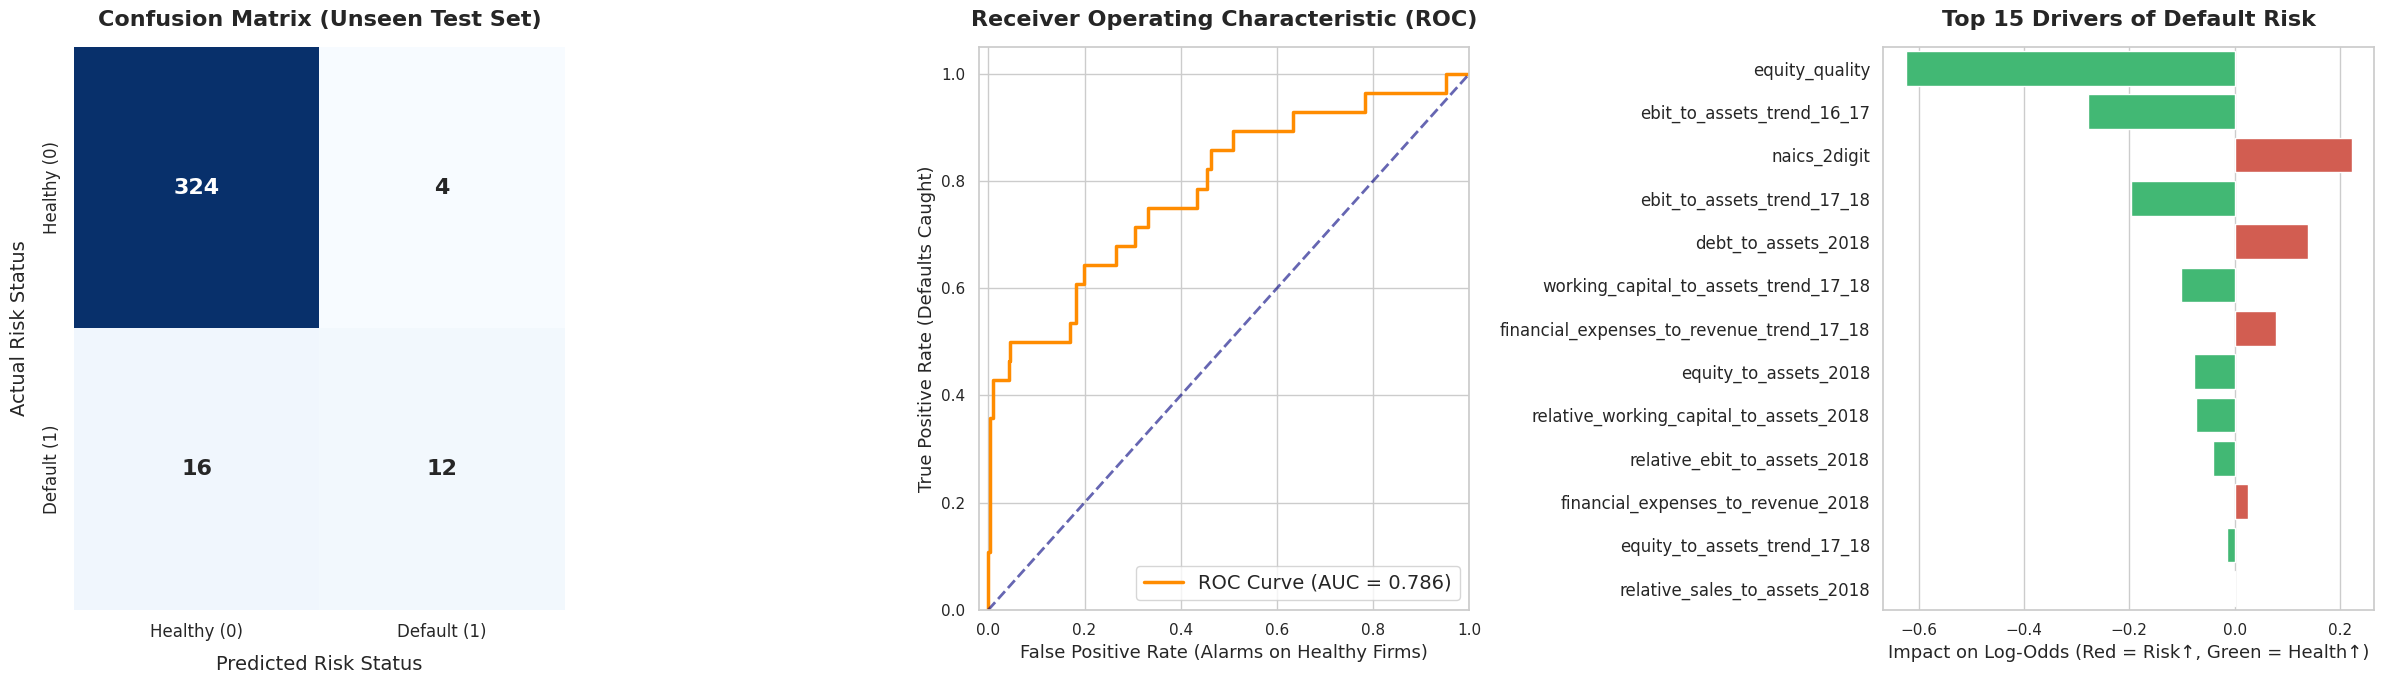

In [6]:
# ====================================================================
# BLOCK 5: EXECUTIVE VISUALIZATIONS (DASHBOARD)
# ====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

print("\n Generating Visual Dashboard...")

# Set up a 1x3 visual dashboard
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. CONFUSION MATRIX HEATMAP
# ---------------------------------------------------------
# Formatting the matrix to look professional and readable
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            ax=axes[0], annot_kws={"size": 16, "weight": "bold"})

axes[0].set_title('Confusion Matrix (Unseen Test Set)', fontsize=16, weight='bold', pad=15)
axes[0].set_xlabel('Predicted Risk Status', fontsize=14, labelpad=10)
axes[0].set_ylabel('Actual Risk Status', fontsize=14, labelpad=10)
axes[0].set_xticklabels(['Healthy (0)', 'Default (1)'], fontsize=12)
axes[0].set_yticklabels(['Healthy (0)', 'Default (1)'], fontsize=12, va='center')

# ---------------------------------------------------------
# 2. ROC-AUC CURVE
# ---------------------------------------------------------
# Calculate True Positive & False Positive rates
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6)
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Alarms on Healthy Firms)', fontsize=13)
axes[1].set_ylabel('True Positive Rate (Defaults Caught)', fontsize=13)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=16, weight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=14)

# ---------------------------------------------------------
# 3. FEATURE COEFFICIENT ANALYSIS
# ---------------------------------------------------------
# Extract the active coefficients from the finalized model
final_classifier = summary_pipeline.named_steps['classifier']
coefs = final_classifier.coef_[0]

# Map them to the feature names
coef_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': coefs
})

# Calculate absolute importance to find the Top 15 drivers
coef_df['Abs_Importance'] = coef_df['Coefficient'].abs()
top_coefs = coef_df.sort_values(by='Abs_Importance', ascending=False).head(15)

# Color coding: Red = Increases Default Risk, Green = Reduces Default Risk
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=top_coefs, ax=axes[2], palette=colors)

axes[2].set_title('Top 15 Drivers of Default Risk', fontsize=16, weight='bold', pad=15)
axes[2].set_xlabel('Impact on Log-Odds (Red = Risk↑, Green = Health↑)', fontsize=13)
axes[2].set_ylabel('')
axes[2].tick_params(axis='y', labelsize=12)

# Adjust layout for a clean fit
plt.tight_layout()
plt.show()

Block 1: Environment Setup & Infrastructure
This section initializes our analytical environment by importing essential libraries for data manipulation (pandas, numpy), visualization (seaborn), and machine learning (scikit-learn). We specifically include category_encoders to handle industry-specific data (NAICS codes) and LogisticRegression to maintain a high degree of model interpretability, which is a gold standard in credit risk scoring.

Block 2: Feature Engineering & Financial Intelligence
This is the "brain" of the model. We don't just look at raw numbers; we transform them into standard financial ratios and momentum indicators to capture the true health of a firm:

Classic Solvency Ratios: We calculate metrics like Working Capital to Assets and Equity to Assets to measure a firm’s buffer against short-term shocks.

Performance Momentum: By calculating trends between 2016 and 2018, we capture whether a firm is in a "death spiral" or a recovery phase.

Sector-Relative Benchmarking: A firm’s health is relative to its peers. We calculate the difference between a firm’s ratios and its industry median to identify "underperformers" within specific sectors.

Blind-Spot Correctors: We include specific "antidotes" like EBIT Crash and Solvency Drop to flag sudden, sharp deteriorations that static ratios might miss.

Block 3: Model Exploration & Hyperparameter Tuning
In this phase, we use a GridSearchCV approach to find the most effective model configuration.

Lasso (L1) Penalty: We use Lasso regularization to perform "automatic feature selection," effectively silencing noise by pushing the coefficients of less important variables to zero.

Class Weighting: Since default events are typically rare (imbalanced data), we test various weights to ensure the model doesn't ignore the minority "Default" class.

Threshold Optimization: Rather than using a default 0.5 probability, we calculate the Optimal Threshold using a Precision-Recall curve to find the "sweet spot" that maximizes our F1-score.

Block 4: The Final Tailored Model
Based on the insights from our exploration, we build the final, production-ready model. We apply a Manual Economic Override to ensure the model remains logical for stakeholders—for instance, prioritizing recent 2018 trends over older data to maintain a consistent narrative. We then apply our mathematically locked threshold to classify firms into "Healthy" or "At Risk".

Block 5: Executive Dashboard & Driver Analysis
The final step translates complex math into actionable insights:

Confusion Matrix: Shows exactly how many defaults we caught (True Positives) versus how many "False Alarms" we generated.

ROC-AUC Curve: Provides a single metric of the model’s ability to distinguish between healthy and failing firms.

Top 15 Drivers: We visualize the most influential features. This allows stakeholders to see exactly which financial behaviors (e.g., high debt or dropping EBIT) are the primary predictors of risk in our model.

In [7]:
# ====================================================================
# BLOCK 6: RETRAIN FINAL MODEL ON 100% OF AVAILABLE DATA
# ====================================================================
print("Preparing full dataset for final production training...")

# 1. Use the entirety of df_clean for training (Train + Test combined)
X_full = df_clean[all_features].copy()
y_full = df_clean['target'].copy()

# 2. Calculate Sector Medians on the FULL training set
for ratio in base_ratios_2018:
    full_train_medians = X_full.groupby('naics_2digit')[ratio].median()
    X_full[f'relative_{ratio}'] = X_full[ratio] - X_full['naics_2digit'].map(full_train_medians)
    X_full[f'relative_{ratio}'] = X_full[f'relative_{ratio}'].fillna(0)

# 3. Filter to the finalized features chosen in Block 4
X_full_final = X_full[FINAL_FEATURES]

# 4. Initialize Production Pipeline
final_production_pipeline = Pipeline([
    ('encoder', TargetEncoder(cols=['naics_2digit']) if 'naics_2digit' in FINAL_FEATURES else 'passthrough'),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(**FINAL_PARAMS))
])

# 5. GENERATE OUT-OF-FOLD PREDICTIONS FOR HONEST VISUALIZATIONS
print("Generating Out-Of-Fold predictions for unbiased full-dataset evaluation...")
y_prob_full_oof = cross_val_predict(
    final_production_pipeline, X_full_final, y_full, cv=5, method='predict_proba'
)[:, 1]

# Apply the mathematically locked threshold from Block 3
y_pred_full_oof = (y_prob_full_oof >= optimal_threshold).astype(int)

# 6. Fit Final Model on 100% of data for future unseen predictions
print("Fitting Final Model on 100% of data...")
final_production_pipeline.fit(X_full_final, y_full)
print("✅ Model successfully trained and ready for production.")

Preparing full dataset for final production training...
Generating Out-Of-Fold predictions for unbiased full-dataset evaluation...
Fitting Final Model on 100% of data...
✅ Model successfully trained and ready for production.



Generating Production Dashboard...


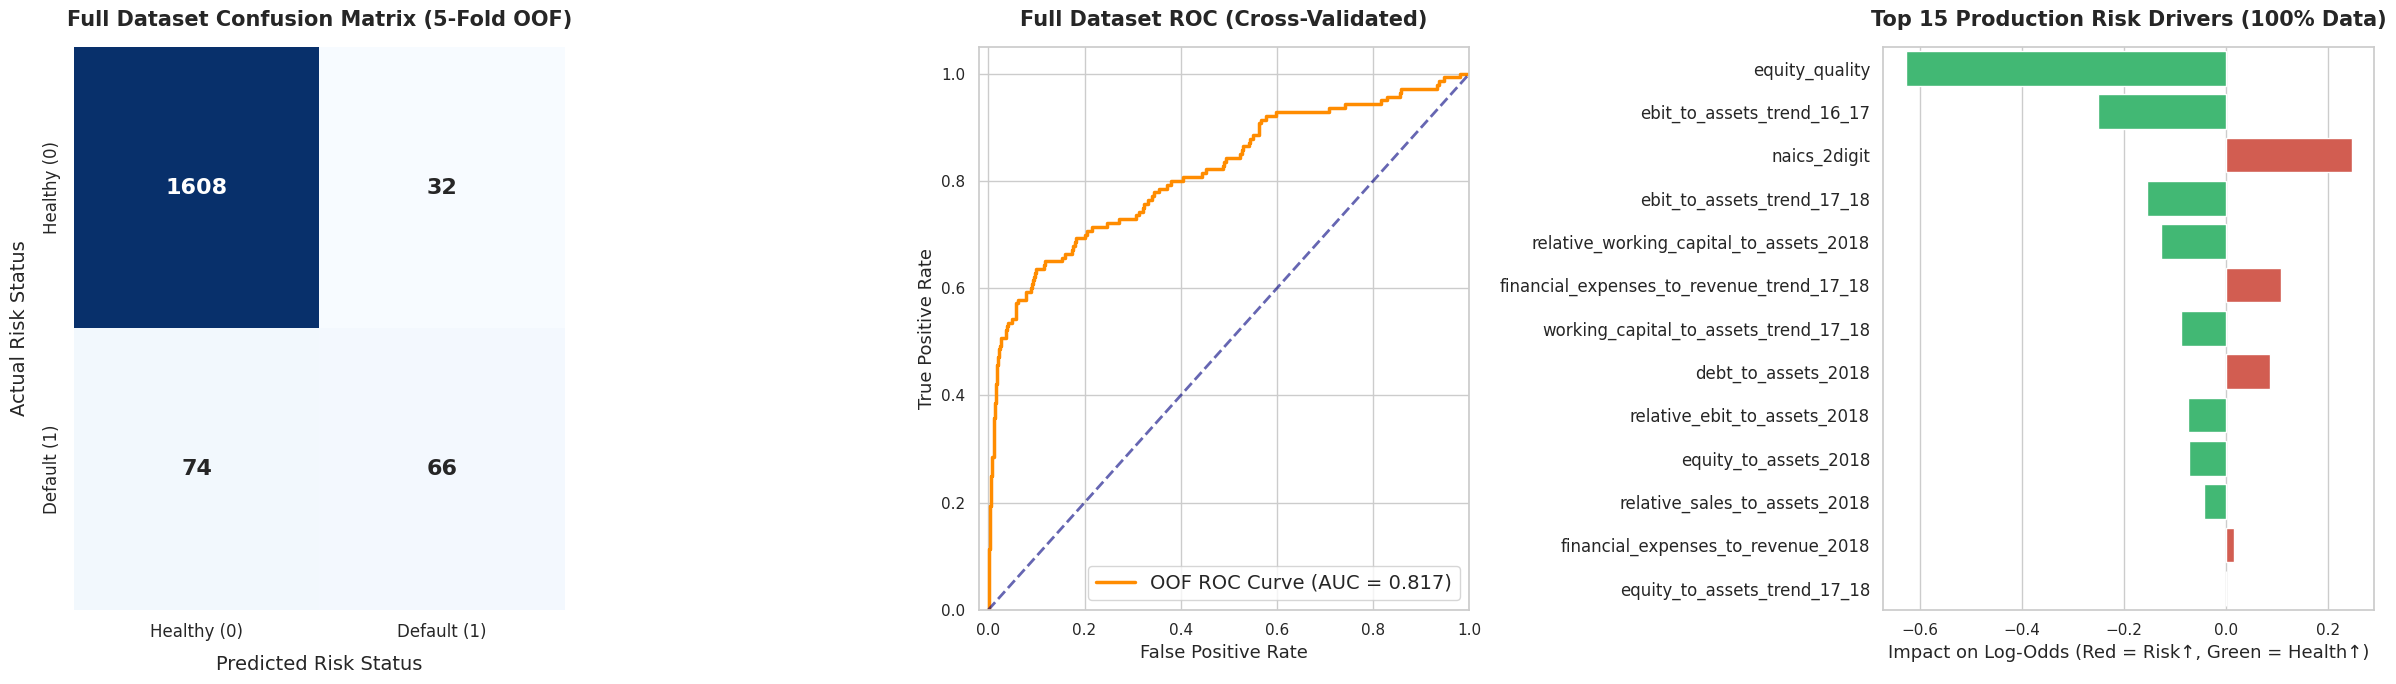


--- FULL DATASET PERFORMANCE (OUT-OF-FOLD) ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1640
           1       0.67      0.47      0.55       140

    accuracy                           0.94      1780
   macro avg       0.81      0.73      0.76      1780
weighted avg       0.93      0.94      0.94      1780



In [8]:
# ====================================================================
# BLOCK 7: FULL PRODUCTION MODEL DASHBOARD (OOF METRICS)
# ====================================================================
from sklearn.metrics import roc_curve, auc

print("\nGenerating Production Dashboard...")

# Set up a 1x3 visual dashboard
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. FULL DATA CONFUSION MATRIX (Out-of-Fold)
# ---------------------------------------------------------
cm_full = confusion_matrix(y_full, y_pred_full_oof)
sns.heatmap(cm_full, annot=True, fmt='g', cmap='Blues', cbar=False,
            ax=axes[0], annot_kws={"size": 16, "weight": "bold"})

axes[0].set_title('Full Dataset Confusion Matrix (5-Fold OOF)', fontsize=15, weight='bold', pad=15)
axes[0].set_xlabel('Predicted Risk Status', fontsize=14, labelpad=10)
axes[0].set_ylabel('Actual Risk Status', fontsize=14, labelpad=10)
axes[0].set_xticklabels(['Healthy (0)', 'Default (1)'], fontsize=12)
axes[0].set_yticklabels(['Healthy (0)', 'Default (1)'], fontsize=12, va='center')

# ---------------------------------------------------------
# 2. FULL DATA ROC-AUC CURVE (Out-of-Fold)
# ---------------------------------------------------------
fpr_full, tpr_full, _ = roc_curve(y_full, y_prob_full_oof)
roc_auc_full = auc(fpr_full, tpr_full)

axes[1].plot(fpr_full, tpr_full, color='darkorange', lw=2.5, label=f'OOF ROC Curve (AUC = {roc_auc_full:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6)
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=13)
axes[1].set_ylabel('True Positive Rate', fontsize=13)
axes[1].set_title('Full Dataset ROC (Cross-Validated)', fontsize=15, weight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=14)

# ---------------------------------------------------------
# 3. PRODUCTION FEATURE COEFFICIENT ANALYSIS
# ---------------------------------------------------------
# Extract the active coefficients from the finalized model (trained on 100% data)
prod_classifier = final_production_pipeline.named_steps['classifier']
prod_coefs = prod_classifier.coef_[0]

prod_coef_df = pd.DataFrame({
    'Feature': X_full_final.columns,
    'Coefficient': prod_coefs
})

prod_coef_df['Abs_Importance'] = prod_coef_df['Coefficient'].abs()
top_prod_coefs = prod_coef_df.sort_values(by='Abs_Importance', ascending=False).head(15)

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_prod_coefs['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=top_prod_coefs, ax=axes[2], palette=colors)

axes[2].set_title('Top 15 Production Risk Drivers (100% Data)', fontsize=15, weight='bold', pad=15)
axes[2].set_xlabel('Impact on Log-Odds (Red = Risk↑, Green = Health↑)', fontsize=13)
axes[2].set_ylabel('')
axes[2].tick_params(axis='y', labelsize=12)

# Adjust layout for a clean fit
plt.tight_layout()
plt.show()

# Print Final Classification Report
print("\n--- FULL DATASET PERFORMANCE (OUT-OF-FOLD) ---")
print(classification_report(y_full, y_pred_full_oof))

In [11]:
# ====================================================================
# BLOCK 8: BULLETPROOF PREDICTION ON UNSEEN TEST DATA
# ====================================================================
import pandas as pd
import numpy as np

# Adjust filenames to match your exact local Excel files
test_file = 'challenge_test_without_target_.xlsx'
sub_template = 'challenge_submission_file.xlsx'

# Define epsilon to prevent division by zero errors in this block
eps = 1e-5

print("Loading unseen test data...")
df_unseen = pd.read_excel(test_file)

# --------------------------------------------------------------------
# 1. EXACT SAME FEATURE ENGINEERING FOR UNSEEN DATA
# --------------------------------------------------------------------
df_unseen['date_of_incorporation'] = pd.to_datetime(df_unseen['Date of incorporation'], errors='coerce')
df_unseen['firm_age'] = 2018 - df_unseen['date_of_incorporation'].dt.year
df_unseen['naics_2digit'] = df_unseen['NAICS 2022, core code (4 digits)'].astype(str).str[:2]

for yr in [2016, 2017, 2018]:
    ta = df_unseen[f'Total assets th EUR {yr}']
    ca = df_unseen[f'Current assets th EUR {yr}']
    cl = df_unseen[f'Current liabilities th EUR {yr}']
    sf = df_unseen[f'Shareholders funds th EUR {yr}']
    ebit = df_unseen[f'Operating profit (loss) [EBIT] th EUR {yr}']
    sales = df_unseen[f'Sales th EUR {yr}']
    rev = df_unseen[f'Operating revenue (Turnover) th EUR {yr}']
    fe = df_unseen[f'Financial expenses th EUR {yr}']
    debt = df_unseen[f'Long term debt th EUR {yr}'] + df_unseen[f'Loans & short-term debt th EUR {yr}']

    df_unseen[f'working_capital_to_assets_{yr}']     = ((ca - cl) / (ta + eps)).clip(-5, 5)
    df_unseen[f'ebit_to_assets_{yr}']                = (ebit / (ta + eps)).clip(-5, 5)
    df_unseen[f'equity_to_assets_{yr}']              = (sf / (ta + eps)).clip(-5, 5)
    df_unseen[f'debt_to_assets_{yr}']                = (debt / (ta + eps)).clip(0, 5)
    df_unseen[f'sales_to_assets_{yr}']               = (sales / (ta + eps)).clip(0, 5)
    df_unseen[f'financial_expenses_to_revenue_{yr}'] = (fe / (rev + eps)).clip(0, 2)

for i, name in ratio_map.items():
    r16 = df_unseen[f'{name}_2016']
    r17 = df_unseen[f'{name}_2017']
    r18 = df_unseen[f'{name}_2018']
    df_unseen[f'{name}_trend_16_17'] = ((r17 - r16) / (r16.abs() + eps)).clip(-3, 3)
    df_unseen[f'{name}_trend_17_18'] = ((r18 - r17) / (r17.abs() + eps)).clip(-3, 3)

df_unseen['equity_quality'] = (df_unseen['Other shareholders funds th EUR 2018'] / (df_unseen['Shareholders funds th EUR 2018'].abs() + eps)).clip(-2, 2)
df_unseen['solvency_drop'] = df_unseen['equity_to_assets_2018'] - df_unseen['equity_to_assets_2017']
df_unseen['ebit_crash'] = df_unseen['ebit_to_assets_2018'] - df_unseen['ebit_to_assets_2017']
df_unseen['working_capital_drain'] = df_unseen['working_capital_to_assets_2018'] - df_unseen['working_capital_to_assets_2017']

df_unseen = df_unseen.replace([np.inf, -np.inf], np.nan)

# PREVENT DATA LEAKAGE: Apply Medians strictly from the FULL TRAINING DATA
for ratio in base_ratios_2018:
    # We group by X_full here to ensure medians come from training data, not unseen data
    full_train_medians = X_full.groupby('naics_2digit')[ratio].median()
    df_unseen[f'relative_{ratio}'] = df_unseen[ratio] - df_unseen['naics_2digit'].map(full_train_medians)
    df_unseen[f'relative_{ratio}'] = df_unseen[f'relative_{ratio}'].fillna(0) # Fill for missing NAICS codes

# Filter down to the final features in the exact required order
X_unseen = df_unseen[FINAL_FEATURES]

# --------------------------------------------------------------------
# 2. PREDICT PROBABILITIES & APPLY THRESHOLD
# --------------------------------------------------------------------
print("Predicting on unseen data...")
unseen_probs = final_production_pipeline.predict_proba(X_unseen)[:, 1]
unseen_preds = (unseen_probs >= optimal_threshold).astype(int)

# Create a dictionary mapping firm_id directly to the prediction
# This is mathematically the safest way to prevent row shuffling
prediction_dict = dict(zip(df_unseen['firm_id'], unseen_preds))


# --------------------------------------------------------------------
# 3. BULLETPROOF FORMATTING & SUBMISSION
# --------------------------------------------------------------------
print("Formatting submission file...")
submission_template = pd.read_excel(sub_template)

# Map the predictions directly onto the template's firm_id.
# This guarantees the template's original row order is 100% preserved.
submission_template['predicted_label'] = submission_template['firm_id'].map(prediction_dict)

# Fill any missing mappings safely just in case a firm_id wasn't found (default to 0 / healthy)
submission_template['predicted_label'] = submission_template['predicted_label'].fillna(0).astype(int)

# Keep only the two required columns for the final file
submission_final = submission_template[['firm_id', 'predicted_label']]

# Export to EXCEL
out_filename = 'final_submission.xlsx'
submission_final.to_excel(out_filename, index=False)

print(f"\n✅ Success! Predictions saved to '{out_filename}'.")
print("\nPreview of Submission File:")
print(submission_final.head(15))

Loading unseen test data...
Predicting on unseen data...
Formatting submission file...

✅ Success! Predictions saved to 'final_submission.xlsx'.

Preview of Submission File:
    firm_id  predicted_label
0    700169                0
1    700170                0
2    700098                0
3    700434                0
4    700352                0
5    700287                0
6    700123                0
7    700272                0
8    700235                0
9    700258                0
10   700097                0
11   700259                0
12   700382                0
13   700322                0
14   700141                0


In [10]:
# ====================================================================
# EXTRA: CALCULATE DEFAULT PERCENTAGE IN FINAL SUBMISSION
# ====================================================================
import pandas as pd

# Load the generated submission file
submission_df = pd.read_excel('final_submission.xlsx')

# Calculate totals
total_firms = len(submission_df)
total_defaults = submission_df['predicted_label'].sum() # Summing works because defaults are 1s and healthy are 0s

# Calculate percentage
default_percentage = (total_defaults / total_firms) * 100

print(f"Total Companies Predicted: {total_firms}")
print(f"Predicted Defaults: {total_defaults}")
print(f"Percentage of Predicted Defaults: {default_percentage:.2f}%")

Total Companies Predicted: 446
Predicted Defaults: 27
Percentage of Predicted Defaults: 6.05%
